# Các thư viện và hàm dùng chung

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import joblib

# 1. Hàm đọc và tiền xử lý dữ liệu
def load_and_preprocess_data(filepath, target_col, delimiter=','):
    # Đọc dữ liệu, bỏ qua các dòng lỗi nếu có
    df = pd.read_csv(filepath, sep=delimiter, on_bad_lines='skip')
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[target_col])

    data = df[[target_col]].values.astype('float32')

    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)
    return data_scaled, scaler

# 2. Hàm tạo tập time_steps cho RNN
def create_dataset(dataset, time_steps=1):
    X, Y = [], []
    for i in range(len(dataset) - time_steps - 1):
        a = dataset[i:(i + time_steps), 0]
        X.append(a)
        Y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(Y)

time_steps = 10 # Số bước thời gian dùng để dự báo

In [2]:
import pandas as pd
import numpy as np

# Số lượng dòng dữ liệu mô phỏng (1000 dòng)
n = 1000
time = np.arange(n)

# ---------------------------------------------------------
# 1. raw_sales.csv (Mục tiêu: price)
# Giá nhà biến động theo chu kỳ + xu hướng tăng nhẹ
# ---------------------------------------------------------
price = 50000 + time * 20 + np.sin(time / 10) * 5000 + np.random.normal(0, 1000, n)
df_sales = pd.DataFrame({'price': price})
df_sales.to_csv('raw_sales.csv', index=False)

# ---------------------------------------------------------
# 2. BTC_DATA.csv (Mục tiêu: priceUSD)
# Giá Bitcoin có độ nhiễu cao và biến động mạnh
# ---------------------------------------------------------
priceUSD = 30000 + time * 15 + np.sin(time / 20) * 8000 + np.random.normal(0, 2000, n)
df_btc = pd.DataFrame({'priceUSD': priceUSD})
df_btc.to_csv('BTC_DATA.csv', index=False)

# ---------------------------------------------------------
# 3. household_power_consumption.txt (Mục tiêu: Voltage)
# Điện thế xoay quanh 240V, cách nhau bằng dấu chấm phẩy (;)
# ---------------------------------------------------------
voltage = 240 + np.sin(time / 5) * 3 + np.random.normal(0, 0.5, n)
df_power = pd.DataFrame({'Voltage': voltage})
df_power.to_csv('household_power_consumption.txt', index=False, sep=';')

# ---------------------------------------------------------
# 4. NIFTY_stock_market.csv (Mục tiêu: close)
# Giá cổ phiếu đóng cửa
# ---------------------------------------------------------
close = 15000 + time * 10 + np.sin(time / 15) * 500 + np.random.normal(0, 150, n)
df_nifty = pd.DataFrame({'close': close})
df_nifty.to_csv('NIFTY_stock_market.csv', index=False)

print("Đã tạo thành công 4 file dữ liệu mô phỏng (Mock Data)")
print("Kiểm tra tab 'Files' ở thanh menu bên trái của Colab.")

Đã tạo thành công 4 file dữ liệu mô phỏng (Mock Data)
Kiểm tra tab 'Files' ở thanh menu bên trái của Colab.


# Câu 1

In [3]:
# ==========================================
# CÂU 1: Dự báo giá nhà (price) - raw_sales.csv
# ==========================================
print("=== CÂU 1 ===")
dataset_1, scaler_1 = load_and_preprocess_data('raw_sales.csv', 'price', delimiter=',')

# Chia tập Train/Test (80/20)
train_size = int(len(dataset_1) * 0.8)
train_1, test_1 = dataset_1[0:train_size, :], dataset_1[train_size:len(dataset_1), :]

trainX_1, trainY_1 = create_dataset(train_1, time_steps)
testX_1, testY_1 = create_dataset(test_1, time_steps)

# Reshape input [samples, time_steps, features]
trainX_1 = np.reshape(trainX_1, (trainX_1.shape[0], trainX_1.shape[1], 1))
testX_1 = np.reshape(testX_1, (testX_1.shape[0], testX_1.shape[1], 1))

# Xây dựng mô hình
model_1 = Sequential()
model_1.add(SimpleRNN(16, input_shape=(time_steps, 1), activation='relu'))
model_1.add(Dense(1))
model_1.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện
model_1.fit(trainX_1, trainY_1, epochs=20, batch_size=32, verbose=1)

# Lưu mô hình & scaler để dùng cho Web App
model_1.save('model_cau1.h5')
joblib.dump(scaler_1, 'scaler_cau1.save')
print("Đã lưu model_cau1.h5 và scaler_cau1.save")

=== CÂU 1 ===
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3075
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1529
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0877
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0510
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0289
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0175
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0125
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0102
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0088
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074
Epoch 16/20
25/25 ━━━━━━━━━━━━

Đã lưu model_cau1.h5 và scaler_cau1.save


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


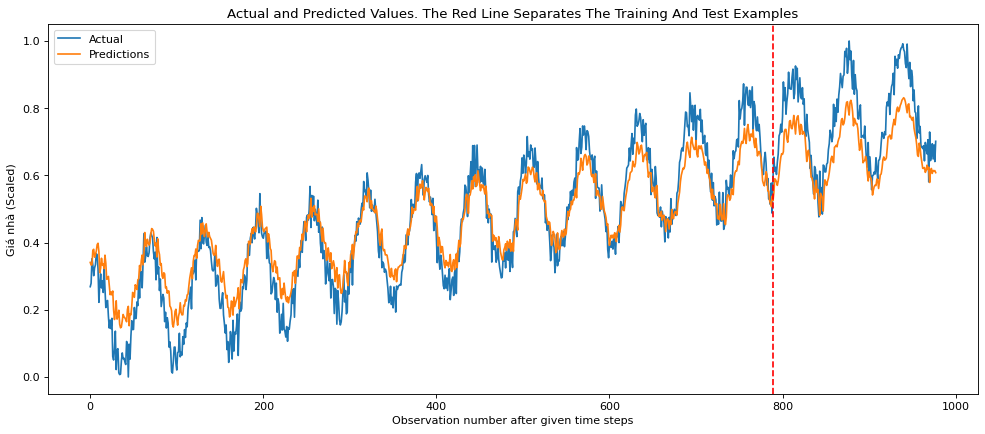

In [9]:
# ==========================================
# PHẦN BỔ SUNG: DỰ BÁO VÀ VẼ BIỂU ĐỒ ĐÁNH GIÁ
# ==========================================

# 1. Thực hiện dự báo trên tập Train và Test
train_predict_1 = model_1.predict(trainX_1)
test_predict_1 = model_1.predict(testX_1)

# 2. Định nghĩa hàm vẽ biểu đồ
def plot_result(trainY, testY, train_predict, test_predict, ylabel_name='Giá trị scaled'):
    # Nối dữ liệu thực tế và dữ liệu dự báo
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    # Cấu hình biểu đồ
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual')
    plt.plot(range(rows), predictions, label='Predictions')

    # Vẽ đường thẳng đỏ phân cách tập Train và Test
    plt.axvline(x=len(trainY), color='r', linestyle='--')

    plt.legend()
    plt.xlabel('Observation number after given time steps')
    plt.ylabel(ylabel_name)
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

# 3. Gọi hàm để hiển thị biểu đồ
plot_result(trainY_1, testY_1, train_predict_1, test_predict_1, ylabel_name='Giá nhà (Scaled)')

# Câu 2

In [4]:
# ==========================================
# CÂU 2: Dự báo giá USD (priceUSD) - BTC_DATA.csv
# ==========================================
print("=== BẮT ĐẦU CÂU 2 ===")
dataset_2, scaler_2 = load_and_preprocess_data('BTC_DATA.csv', 'priceUSD', delimiter=',')

train_size = int(len(dataset_2) * 0.8)
train_2, test_2 = dataset_2[0:train_size, :], dataset_2[train_size:len(dataset_2), :]

trainX_2, trainY_2 = create_dataset(train_2, time_steps)
testX_2, testY_2 = create_dataset(test_2, time_steps)

trainX_2 = np.reshape(trainX_2, (trainX_2.shape[0], trainX_2.shape[1], 1))
testX_2 = np.reshape(testX_2, (testX_2.shape[0], testX_2.shape[1], 1))

model_2 = Sequential()
model_2.add(SimpleRNN(16, input_shape=(time_steps, 1), activation='relu'))
model_2.add(Dense(1))
model_2.compile(optimizer='adam', loss='mean_squared_error')

model_2.fit(trainX_2, trainY_2, epochs=20, batch_size=32, verbose=1)

model_2.save('model_cau2.h5')
joblib.dump(scaler_2, 'scaler_cau2.save')
print("Đã lưu model_cau2.h5 và scaler_cau2.save")

=== BẮT ĐẦU CÂU 2 ===
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0264
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0050
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0051
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0051
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049
Epoch 16/20
25/25 ━━━━━━━

Đã lưu model_cau2.h5 và scaler_cau2.save


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


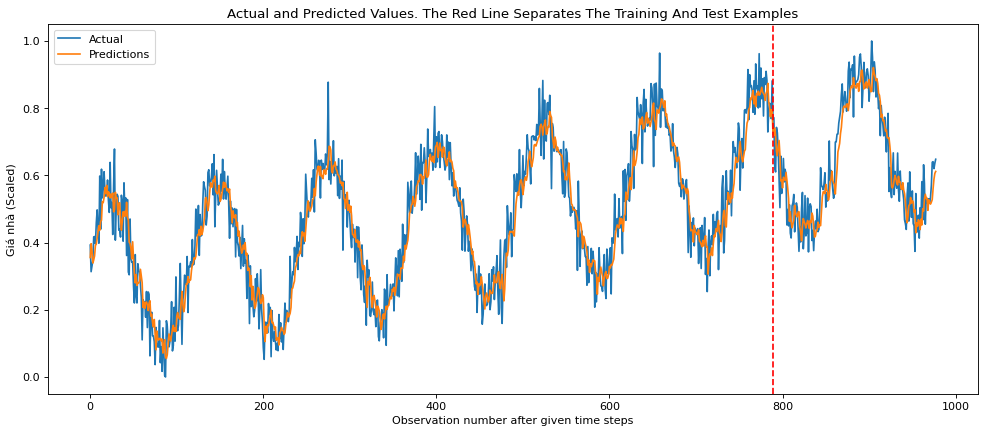

In [10]:
# ==========================================
# PHẦN BỔ SUNG: DỰ BÁO VÀ VẼ BIỂU ĐỒ ĐÁNH GIÁ
# ==========================================

# 1. Thực hiện dự báo trên tập Train và Test
train_predict_2 = model_2.predict(trainX_2)
test_predict_2 = model_2.predict(testX_2)

# 2. Định nghĩa hàm vẽ biểu đồ
def plot_result(trainY, testY, train_predict, test_predict, ylabel_name='Giá trị scaled'):
    # Nối dữ liệu thực tế và dữ liệu dự báo
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    # Cấu hình biểu đồ
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual')
    plt.plot(range(rows), predictions, label='Predictions')

    # Vẽ đường thẳng đỏ phân cách tập Train và Test
    plt.axvline(x=len(trainY), color='r', linestyle='--')

    plt.legend()
    plt.xlabel('Observation number after given time steps')
    plt.ylabel(ylabel_name)
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

# 3. Gọi hàm để hiển thị biểu đồ
plot_result(trainY_2, testY_2, train_predict_2, test_predict_2, ylabel_name='Giá nhà (Scaled)')

# Câu 3


In [5]:
# ==========================================
# CÂU 3: Dự báo điện thế (Voltage) - household_power_consumption.txt
# ==========================================
print("=== CÂU 3 ===")
# File này thường dùng dấu chấm phẩy
dataset_3, scaler_3 = load_and_preprocess_data('household_power_consumption.txt', 'Voltage', delimiter=';')

train_size = int(len(dataset_3) * 0.8)
train_3, test_3 = dataset_3[0:train_size, :], dataset_3[train_size:len(dataset_3), :]

trainX_3, trainY_3 = create_dataset(train_3, time_steps)
testX_3, testY_3 = create_dataset(test_3, time_steps)

trainX_3 = np.reshape(trainX_3, (trainX_3.shape[0], trainX_3.shape[1], 1))
testX_3 = np.reshape(testX_3, (testX_3.shape[0], testX_3.shape[1], 1))

model_3 = Sequential()
model_3.add(SimpleRNN(16, input_shape=(time_steps, 1), activation='relu'))
model_3.add(Dense(1))
model_3.compile(optimizer='adam', loss='mean_squared_error')

model_3.fit(trainX_3, trainY_3, epochs=20, batch_size=32, verbose=1)

model_3.save('model_cau3.h5')
joblib.dump(scaler_3, 'scaler_cau3.save')
print("Đã lưu model_cau3.h5 và scaler_cau3.save")

=== CÂU 3 ===
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5275
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1830
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0643
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0202
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0153
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0135
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0120
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0053
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0050
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0048
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0048
Epoch 16/20
25/25 ━━━━━━━━━━━━

Đã lưu model_cau3.h5 và scaler_cau3.save


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


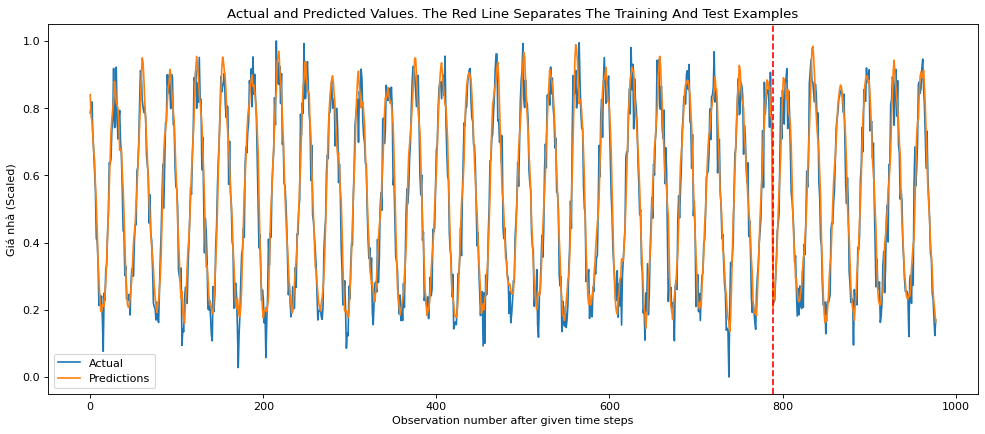

In [11]:
# ==========================================
# PHẦN BỔ SUNG: DỰ BÁO VÀ VẼ BIỂU ĐỒ ĐÁNH GIÁ
# ==========================================

# 1. Thực hiện dự báo trên tập Train và Test
train_predict_3 = model_3.predict(trainX_3)
test_predict_3 = model_3.predict(testX_3)

# 2. Định nghĩa hàm vẽ biểu đồ
def plot_result(trainY, testY, train_predict, test_predict, ylabel_name='Giá trị scaled'):
    # Nối dữ liệu thực tế và dữ liệu dự báo
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    # Cấu hình biểu đồ
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual')
    plt.plot(range(rows), predictions, label='Predictions')

    # Vẽ đường thẳng đỏ phân cách tập Train và Test
    plt.axvline(x=len(trainY), color='r', linestyle='--')

    plt.legend()
    plt.xlabel('Observation number after given time steps')
    plt.ylabel(ylabel_name)
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

# 3. Gọi hàm để hiển thị biểu đồ
plot_result(trainY_3, testY_3, train_predict_3, test_predict_3, ylabel_name='Giá nhà (Scaled)')

# Câu 4

In [6]:
# ==========================================
# CÂU 4: Dự báo tỉ giá cổ phiếu (close) - NIFTY_stock_market.csv
# ==========================================
print("=== CÂU 4 ===")
dataset_4, scaler_4 = load_and_preprocess_data('NIFTY_stock_market.csv', 'close', delimiter=',')

train_size = int(len(dataset_4) * 0.8)
train_4, test_4 = dataset_4[0:train_size, :], dataset_4[train_size:len(dataset_4), :]

trainX_4, trainY_4 = create_dataset(train_4, time_steps)
testX_4, testY_4 = create_dataset(test_4, time_steps)

trainX_4 = np.reshape(trainX_4, (trainX_4.shape[0], trainX_4.shape[1], 1))
testX_4 = np.reshape(testX_4, (testX_4.shape[0], testX_4.shape[1], 1))

model_4 = Sequential()
model_4.add(SimpleRNN(16, input_shape=(time_steps, 1), activation='relu'))
model_4.add(Dense(1))
model_4.compile(optimizer='adam', loss='mean_squared_error')

model_4.fit(trainX_4, trainY_4, epochs=20, batch_size=32, verbose=1)

model_4.save('model_cau4.h5')
joblib.dump(scaler_4, 'scaler_cau4.save')
print("Đã lưu model_cau4.h5 và scaler_cau4.save")

=== CÂU 4 ===
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5376e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7082e-04
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5952e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6976e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8035e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6264e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6329e-04
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6153e-04
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6038e-04
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6081e-04
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6522e-04
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6321e-04
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6456e-04
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

Đã lưu model_cau4.h5 và scaler_cau4.save


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


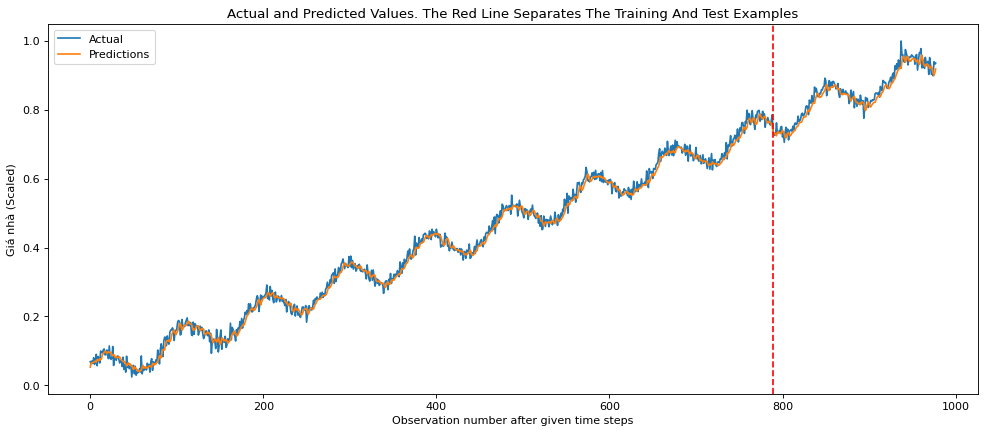

In [12]:
# ==========================================
# PHẦN BỔ SUNG: DỰ BÁO VÀ VẼ BIỂU ĐỒ ĐÁNH GIÁ
# ==========================================

# 1. Thực hiện dự báo trên tập Train và Test
train_predict_4 = model_4.predict(trainX_4)
test_predict_4 = model_4.predict(testX_4)

# 2. Định nghĩa hàm vẽ biểu đồ
def plot_result(trainY, testY, train_predict, test_predict, ylabel_name='Giá trị scaled'):
    # Nối dữ liệu thực tế và dữ liệu dự báo
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    # Cấu hình biểu đồ
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual')
    plt.plot(range(rows), predictions, label='Predictions')

    # Vẽ đường thẳng đỏ phân cách tập Train và Test
    plt.axvline(x=len(trainY), color='r', linestyle='--')

    plt.legend()
    plt.xlabel('Observation number after given time steps')
    plt.ylabel(ylabel_name)
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

# 3. Gọi hàm để hiển thị biểu đồ
plot_result(trainY_4, testY_4, train_predict_4, test_predict_4, ylabel_name='Giá nhà (Scaled)')

# Câu 5

Cài đặt thư viện cho web app

In [7]:
!pip install flask pyngrok

In [15]:
import os
from flask import Flask, request, render_template_string
from pyngrok import ngrok
from keras.models import load_model
import numpy as np
import joblib

# 1. Thêm Authtoken
!ngrok config add-authtoken 3Emr0RLQplAf2nVq6YVHDCCNSaN_LGFKHkg1b4WvBqXdEQaw

app = Flask(__name__)

# 2. Load sẵn model và scaler (Mặc định đang chạy Câu 1. Có thể đổi sang model_cau2, model_cau3...)
model = load_model('model_cau1.h5')
scaler = joblib.load('scaler_cau1.save')

# 3. Giao diện HTML
HTML_TEMPLATE = '''
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>HUIT AI Forecaster | RNN Model</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;800&display=swap" rel="stylesheet">
    <style>
        :root {
            --primary: #4F46E5;
            --bg: #F3F4F6;
            --surface: #FFFFFF;
            --text-main: #1F2937;
            --text-muted: #6B7280;
        }
        body {
            font-family: 'Inter', sans-serif;
            background-color: var(--bg);
            color: var(--text-main);
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 100vh;
            margin: 0;
        }
        .card {
            background: var(--surface);
            padding: 40px;
            border-radius: 20px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.05);
            width: 100%;
            max-width: 500px;
        }
        .header { text-align: center; margin-bottom: 30px; }
        .header h1 { margin: 0; font-size: 28px; font-weight: 800; color: var(--primary); }
        .header p { margin: 5px 0 0; color: var(--text-muted); font-size: 14px; font-weight: 600; }

        .form-group { margin-bottom: 20px; }
        label { display: block; margin-bottom: 8px; font-weight: 600; font-size: 14px; }
        input[type="text"] {
            width: 100%;
            padding: 14px 16px;
            border: 2px solid #E5E7EB;
            border-radius: 10px;
            font-size: 15px;
            transition: all 0.3s ease;
            box-sizing: border-box;
        }
        input[type="text"]:focus { outline: none; border-color: var(--primary); }

        button {
            width: 100%;
            background: var(--primary);
            color: white;
            border: none;
            padding: 14px;
            border-radius: 10px;
            font-size: 16px;
            font-weight: 600;
            cursor: pointer;
            transition: transform 0.1s, background 0.3s;
        }
        button:hover { background: #4338CA; transform: translateY(-2px); }

        .result-box {
            margin-top: 25px;
            padding: 20px;
            border-radius: 12px;
            background: #EEF2FF;
            border: 1px dashed #A5B4FC;
            text-align: center;
        }
        .result-title { font-size: 14px; color: var(--text-muted); margin-bottom: 5px; font-weight: 600;}
        .result-value { font-size: 32px; font-weight: 800; color: var(--primary); }

        .error-box {
            background: #FEF2F2;
            border: 1px dashed #FCA5A5;
            color: #DC2626;
        }
    </style>
</head>
<body>
    <div class="card">
        <div class="header">
            <h1>HUIT AI</h1>
            <p> <3 </p>
        </div>

        <form action="/predict" method="post">
            <div class="form-group">
                <label>Nhập 10 giá trị lịch sử gần nhất</label>
                <input type="text" name="input_data" placeholder="VD: 100, 105.5, 102, 108..." required autocomplete="off">
            </div>
            <button type="submit">Phân Tích Ngay </button>
        </form>

        {% if prediction %}
            {% if error %}
                <div class="result-box error-box">
                    <div class="result-value" style="font-size: 16px;">{{ prediction }}</div>
                </div>
            {% else %}
                <div class="result-box">
                    <div class="result-title">Kết Quả Dự Báo Tiếp Theo</div>
                    <div class="result-value">{{ prediction }}</div>
                </div>
            {% endif %}
        {% endif %}
    </div>
</body>
</html>
'''

# 4. Định tuyến các trang web
@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        input_str = request.form['input_data']
        # Lọc dữ liệu, loại bỏ khoảng trắng dư thừa
        input_list = [float(x.strip()) for x in input_str.split(',')]

        # Kiểm tra logic
        if len(input_list) != 10:
            return render_template_string(HTML_TEMPLATE, prediction="Lỗi: Cần nhập chính xác 10 giá trị!", error=True)

        # Xử lý ma trận cho mô hình
        input_array = np.array(input_list).reshape(-1, 1)
        input_scaled = scaler.transform(input_array)
        input_reshaped = input_scaled.reshape(1, 10, 1)

        # Dự báo
        prediction_scaled = model.predict(input_reshaped)
        prediction_real = scaler.inverse_transform(prediction_scaled)

        # Định dạng output đẹp mắt (có dấu phẩy phân cách hàng nghìn)
        final_val = "{:,.2f}".format(prediction_real[0][0])
        return render_template_string(HTML_TEMPLATE, prediction=final_val, error=False)

    except ValueError:
         return render_template_string(HTML_TEMPLATE, prediction="Lỗi: Dữ liệu không hợp lệ. Vui lòng chỉ nhập số và dấu phẩy.", error=True)
    except Exception as e:
        return render_template_string(HTML_TEMPLATE, prediction=f"Lỗi hệ thống: {str(e)}", error=True)

# 5. Khởi động máy chủ
# Đóng các tunnel ngrok cũ nếu có để tránh xung đột port
ngrok.kill()

# Mở tunnel mới
public_url = ngrok.connect(5000)
print("="*60)
print(f" HỆ THỐNG ĐÃ SẴN SÀNG HOẠT ĐỘNG!")
print(f" Truy cập giao diện Web App tại: {public_url}")
print("="*60)

if __name__ == '__main__':
    app.run(port=5000)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


 HỆ THỐNG ĐÃ SẴN SÀNG HOẠT ĐỘNG!
 Truy cập giao diện Web App tại: NgrokTunnel: "https://hacked-roaming-snowplow.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:28:29] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:28:37] "POST /predict HTTP/1.1" 200 -


...

INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:28:42] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:28:52] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:28:54] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:29:10] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


INFO:werkzeug:127.0.0.1 - - [07/Jun/2026 01:29:12] "POST /predict HTTP/1.1" 200 -
